# End-to-End Text Analytics with Python

## Objective

The objective of this project is to download the novel 'Pride and Prejudice' from Project Gutenberg and perform NLP to analyse the author's vocabulary and writing patterns.

Skills demonstrated
- Web scraping
- HTML parsing
- Text preprocessing
- Natural Language Processing
- Exploratory Data Analysis (EDA)

### Step 1 - Download the Book

The first step is obtaining the HTML version of a novel from Project Gutenberg.

The webpage will be downloaded using the Requests library.

In [104]:
import requests
from bs4 import BeautifulSoup
import nltk
import string

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk import FreqDist

In [105]:
url = "https://www.gutenberg.org/cache/epub/1342/pg1342-images.html"

response = requests.get(url)

In [106]:
response.status_code

200

In [107]:
response.text[:500]

'<!DOCTYPE html>\r\n<html lang="en"><head>\r\n<meta charset="utf-8"><style>\r\n#pg-header div, #pg-footer div {\r\n    all: inherit;\r\n    display: block;\r\n    margin-top: 1em;\r\n    margin-bottom: 1em;\r\n    margin-left: 2em;\r\n}\r\n#pg-footer div.agate {\r\n    font-size: 90%;\r\n    margin-top: 0;\r\n    margin-bottom: 0;\r\n    text-align: center;\r\n}\r\n#pg-footer li {\r\n    all: initial;\r\n    display: block;\r\n    margin-top: 1em;\r\n    margin-bottom: 1em;\r\n    text-indent: -0.6em;\r\n}\r\n#pg-footer div.secthead {\r\n    f'

#### Reflection

The webpage was successfully downloaded using the Requests library.

The downloaded content is HTML rather than plain text because websites communicate using HTML documents.

The HTML contains not only the novel, but also metadata and formatting tags.

### Step 2 - Inspecting the Downloaded Webpage

In [108]:
type(response)

requests.models.Response

In [109]:
response.url

'https://www.gutenberg.org/cache/epub/1342/pg1342-images.html'

In [110]:
len(response.text)

# total number of characters in the HTML document

842294

In [111]:
response.headers

{'date': 'Sat, 11 Jul 2026 11:44:04 GMT', 'server': 'Apache', 'last-modified': 'Wed, 01 Jul 2026 12:56:54 GMT', 'accept-ranges': 'bytes', 'vary': 'Accept-Encoding', 'content-encoding': 'gzip', 'x-backend': 'gutenweb5', 'transfer-encoding': 'chunked', 'content-type': 'text/html; charset=utf-8'}

In [112]:
response.encoding

'utf-8'

#### Reflection

The response object contains much more than the webpage itself.

It also stores information such as the status code, headers, encoding and the final URL.

The actual HTML of the webpage is stored in 'response.text'.

### Step 3 - Saving the Raw Dataset

Instead of downloading the webpage every time the notebook is executed, the raw HTML will be saved locally.

Keeping an untouched copy of the original dataset is good practice because it allows the analytics to be reproduced without repeatedly accessing the website.

In [113]:
import os

os.makedirs("../data/raw", exist_ok=True)

with open(
    "../data/raw/pride_and_prejudice.html",
    "w",
    encoding="utf-8"
) as f:
    f.write(response.text)

print("Raw HTML saved successfully!")

Raw HTML saved successfully!


#### Reflection

The downloaded HTML has been saved locally.

Saving the raw dataset ensures that the original data remains unchanged throughout the project. It also avoids repeatedly downloading the webpage, making the analysis more efficient and reproducible.

### Step 4 - Parsing the HTML

The downloaded webpage is currently stored as a raw HTML document.

BeautifulSoup parses the HTML into a tree structure, allowing the webpage to be explored and queried using Python.

In this section, the saved HTML file will be loaded and parsed.

In [114]:
# reading the file

with open(
    "../data/raw/pride_and_prejudice.html",
    "r",
    encoding="utf-8"
) as f:
    html = f.read()

In [115]:
soup = BeautifulSoup(html, "html.parser")

In [116]:
soup.title

<title>Pride and prejudice | Project Gutenberg</title>

In [117]:
soup.title.string

'Pride and prejudice | Project Gutenberg'

In [118]:
soup.find("h1")

<h1><img alt="" height="600" id="img_images_front.png" src="images/front.png"/>
<br/><br/>
<i>PRIDE.<br/>

and<br/>

PREJUDICE</i></h1>

In [119]:
# finds number of paragraphs

len(soup.find_all("p"))

2147

In [120]:
# finds number of hyperlinks

len(soup.find_all("a"))

729

The webpage contains much more than the novel itself.

It includes HTML tags, hyperlinks, navigation elements and metadata.

The next step is to identify and extract only the text of the novel.

In [121]:
book_text = soup.get_text()

In [122]:
type(book_text)

str

In [123]:
len(book_text)

745600

In [124]:
book_text[:1000]

'\n\n\nPride and prejudice | Project Gutenberg\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\nThe Project Gutenberg eBook of Pride and Prejudice\nThis eBook is for the use of anyone anywhere in the United States and\n\nmost other parts of the world at no cost and with almost no restrictions\n\nwhatsoever. You may copy it, give it away or re-use it under the terms\n\nof the Project Gutenberg License included with this eBook or online\n\nat www.gutenberg.org. If you are not located in the United States,\n\nyou will have to check the laws of the country where you are located\n\nbefore using this eBook.\nTitle: Pride and Prejudice\n\nAuthor: Jane Austen\n\n\nRelease date: June 1, 1998 [eBook #1342]\n\n                Most recently updated: February 10, 2026\nLanguage: English\nOther information and formats: www.gutenberg.org/ebooks/1342\nCredits: Chuck Greif and the Online Distributed Proofreading Team at http://www.pgdp.net (This file was produced from images available at The Internet

The HTML tags have been removed, leaving only the visible text.

However, the extracted text still contains Project Gutenberg metadata, navigation content and other information that is not part of the novel.

Further cleaning will be required before the text can be analysed.

### Step 5 - Locating the Novel

Although the HTML tags have been removed, the extracted text still contains Project Gutenberg metadata before and after the novel.

Before analysing the text, the beginning and end of the actual novel must be identified so that only the novel itself is processed.

In [125]:
book_text[:3000]

'\n\n\nPride and prejudice | Project Gutenberg\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\nThe Project Gutenberg eBook of Pride and Prejudice\nThis eBook is for the use of anyone anywhere in the United States and\n\nmost other parts of the world at no cost and with almost no restrictions\n\nwhatsoever. You may copy it, give it away or re-use it under the terms\n\nof the Project Gutenberg License included with this eBook or online\n\nat www.gutenberg.org. If you are not located in the United States,\n\nyou will have to check the laws of the country where you are located\n\nbefore using this eBook.\nTitle: Pride and Prejudice\n\nAuthor: Jane Austen\n\n\nRelease date: June 1, 1998 [eBook #1342]\n\n                Most recently updated: February 10, 2026\nLanguage: English\nOther information and formats: www.gutenberg.org/ebooks/1342\nCredits: Chuck Greif and the Online Distributed Proofreading Team at http://www.pgdp.net (This file was produced from images available at The Internet

In [126]:
book_text[-3000:]

'dation’s business office is located at 41 Watchung Plaza #516,\n\nMontclair NJ 07042, USA, +1 (862) 621-9288. Email contact links and up\n\nto date contact information can be found at the Foundation’s website\n\nand official page at www.gutenberg.org/contact\n\n\n\nSection 4. Information about Donations to the Project Gutenberg\n\nLiterary Archive Foundation\n\n\n\nProject Gutenberg™ depends upon and cannot survive without widespread\n\npublic support and donations to carry out its mission of\n\nincreasing the number of public domain and licensed works that can be\n\nfreely distributed in machine-readable form accessible by the widest\n\narray of equipment including outdated equipment. Many small donations\n\n($1 to $5,000) are particularly important to maintaining tax exempt\n\nstatus with the IRS.\n\n\n\nThe Foundation is committed to complying with the laws regulating\n\ncharities and charitable donations in all 50 states of the United\n\nStates. Compliance requirements are not uni

#### Step 5.1 - Removing the Project Gutenberg Wrapper

The extracted webpage contains Project Gutenberg metadata before and after the novel.

The first cleaning step is to keep only the content between the official START and END markers.

Further cleaning will be performed afterwards because the book still contains front matter such as the list of illustrations.

In [127]:
start_marker = "*** START OF THE PROJECT GUTENBERG EBOOK"
end_marker = "*** END OF THE PROJECT GUTENBERG EBOOK"

start_index = book_text.find(start_marker)
end_index = book_text.find(end_marker)

book_text = book_text[start_index:end_index]

In [128]:
book_text[:2000]

'*** START OF THE PROJECT GUTENBERG EBOOK PRIDE AND PREJUDICE ***\n\n\n\n\nPREFACE.\nList of Illustrations.\nChapter: I., \nII., \nIII., \nIV., \nV., \nVI., \nVII., \nVIII., \nIX., \nX., \nXI., \nXII., \nXIII., \nXIV., \nXV., \nXVI., \nXVII., \nXVIII., \nXIX., \nXX., \nXXI., \nXXII., \nXXIII., \nXXIV., \nXXV., \nXXVI., \nXXVII., \nXXVIII., \nXXIX., \nXXX., \nXXXI., \nXXXII., \nXXXIII., \nXXXIV., \nXXXV., \nXXXVI., \nXXXVII., \nXXXVIII., \nXXXIX., \nXL., \nXLI., \nXLII., \nXLIII., \nXLIV., \nXLV., \n XLVI., \nXLVII., \nXLVIII., \nXLIX., \nL., \nLI., \nLII., \nLIII., \nLIV., \nLV., \nLVI., \nLVII., \nLVIII., \nLIX., \nLX., \nLXI.\n\n\n\n\n\n\n\n\n\n{iv}\n\n\n{v}\n\n\nPRIDE.\n\nand\n\nPREJUDICE\n\n\nby\n\nJane Austen,\n\n\nwith a Preface by\n\nGeorge Saintsbury\nand\n\nIllustrations by\n\nHugh Thomson\n\n\nRuskin\n\nHouse.\n\n\n\n\n\n156. Charing\n\nCross Road.\n\n\nLondon\n\nGeorge Allen.\n\n\n\n\nCHISWICK PRESS:—CHARLES WHITTINGHAM AND CO.\n\nTOOKS COURT, CHANCERY LANE, LONDON.\n\n{vii}

In [129]:
book_text[-1000:]

'ed its arrangement, she sent him\n\nlanguage so very abusive, especially of Elizabeth, that for some time\n\nall intercourse was at an end. But at length, by Elizabeth’s persuasion,\n\nhe was prevailed on to overlook the offence, and seek a reconciliation;\n\nand, after a little further resistance on the part of his aunt, her\n\nresentment gave way, either to her affection for him, or her curiosity\n\nto see how his wife conducted herself; and she condescended to wait on\n\nthem at Pemberley, in spite of that pollution which its woods had\n\nreceived, not merely from the presence of such a mistress, but the\n\nvisits of her uncle and aunt from the city.\nWith the Gardiners they were always on the most intimate terms. Darcy,\n\nas well as Elizabeth, really loved them; and they were both ever\n\nsensible of the warmest gratitude towards the persons who, by bringing\n\nher into Derbyshire, had been the means of uniting them.\n\n\n\n\n\nCHISWICK PRESS:—CHARLES WHITTINGHAM AND CO.\n\nTOOKS

#### Step 5.2 - Removing Front & Back Matter


In [130]:
start_of_story = book_text.find("Chapter I.")

clean_text = book_text[start_of_story:]

In [131]:
end_of_story = clean_text.find("CHISWICK PRESS")

clean_text = clean_text[:end_of_story]

#### Step 5.3 - Saving the Cleaned Text

The cleaned novel text will be saved separately from the raw HTML.

Keeping intermediate datasets improves reproducibility and avoids repeating cleaning steps.

In [132]:
os.makedirs("../data/processed", exist_ok=True)

with open(
    "../data/processed/pride_and_prejudice_clean.txt",
    "w",
    encoding="utf-8"
) as f:
    f.write(clean_text)

print("Clean text saved successfully!")

Clean text saved successfully!


The cleaned text is now a .txt file.

### Step 6 - Text Preprocessing

Before analysing the novel, the text must be converted into a structured format suitable for Natural Language Processing (NLP).

The preprocessing steps include:

- converting text to lowercase
- tokenization
- removing punctuation
- removing stopwords

In [133]:
#reading the text from the processed file

with open(
    "../data/processed/pride_and_prejudice_clean.txt",
    "r",
    encoding="utf-8"
) as f:
    clean_text = f.read()

In [134]:
clean_text=clean_text.lower()

In [135]:
#tokenizing the text

tokens = word_tokenize(clean_text)

In [136]:
#removing punctuation

tokens_no_punc = []

extra_punctuation = {
    "“",
    "”",
    "’",
    "‘",
    "—",
    "–",
    "…"
}

for word in tokens:
    if (word not in string.punctuation and word not in extra_punctuation):
        tokens_no_punc.append(word)

In [137]:
#normalizing abbreviations like mr. -> mr

normalized_tokens = []

for word in tokens_no_punc:
    normalized_tokens.append(word.rstrip("."))

In [138]:
#removing stopwords

stop_words=stopwords.words("english")

tokens_clean = []

for word in normalized_tokens:
    if word not in stop_words:
        tokens_clean.append(word)

### Step 7 - Exploratory Data Analysis

The cleaned text is now ready for analysis.

This section explores the characteristics of the novel to better understand its vocabulary, writing style and prominent characters.

The analysis aims to answer the following questions:

#### Dataset Overview

- How many total words are in the novel?
- How many unique words are used?
- What proportion of the words are unique (lexical diversity)?

#### Vocabulary Analysis
- Which words appear most frequently?
- Which words dominate after removing stopwords?
- What is the average word length?
- What is the most common word length?
- Which are the longest words used in the novel?

#### Character and Theme Analysis

- Which characters are mentioned most frequently?
- What themes appear to dominate the novel based on the most frequent words?
- How prominent are character names within the novel's vocabulary?

#### Dataset Overview

##### 1. Total Number of Words
Provides an indication of the size of the novel after preprocessing

In [139]:
total_words = len(tokens_clean)

print("Total words:", total_words)

Total words: 55907


##### 2. Vocabulary Size

This refers to the number of unique words used throughout the novel. A larger vocabulary generally indicates greater lexical variety.

In [140]:
unique_words = len(set(tokens_clean))

print("Unique words:", unique_words)

Unique words: 6806


##### 3. Lexical Diversity

This measures the richness of the vocabulary.

Lexical diversity = Unique Words / Total Words

A higher value indicates greater variation in word usage.

In [141]:
lexical_diversity = unique_words / total_words

print(f"Lexical Diversity: {lexical_diversity:.3f}")

Lexical Diversity: 0.122


The lexical diversity of **0.122** indicates that around **12.2%** of the words in the processed text are unique. This reflects a balance between repeated vocabulary such as character names and common dialogue, and a varied writing style.

#### Vocabulary Analysis

##### 4. Most Frequent Words

Since stopwords have already been removed, the remaining words are expected to better represent the novel's themes and characters.

In [142]:
fdist = FreqDist(tokens_clean)

top20 = fdist.most_common(20)

top20

[('mr', 780),
 ('elizabeth', 621),
 ('could', 524),
 ('would', 471),
 ('darcy', 419),
 ('said', 404),
 ('mrs', 348),
 ('much', 330),
 ('bennet', 329),
 ('must', 310),
 ('bingley', 309),
 ('jane', 294),
 ('miss', 284),
 ('one', 269),
 ('know', 239),
 ('never', 227),
 ('though', 226),
 ('soon', 217),
 ('well', 215),
 ('sister', 215)]

The most frequent words are dominated by character names (e.g., **Elizabeth**, **Darcy**, **Bennet**, **Bingley**, and **Jane**), indicating that the narrative is strongly centred around interactions between these characters. 

In addition, dialogue-related words such as **said**, **could**, **would**, and **must** occur frequently, reflecting the conversational nature of the novel. 

Honorifics such as **Mr**, **Mrs**, and **Miss** also appear prominently, highlighting the importance of social status and formal address in *Pride and Prejudice*.

##### 4.1 Most Frequent Words (Excluding Honorifics)

Titles such as **Mr**, **Mrs**, and **Miss** are extremely common in *Pride and Prejudice* because many characters are referred to using formal honorifics.

To better understand the novel's vocabulary and themes, these titles are removed and the frequency distribution is recalculated.

In [143]:
honorifics = {"mr", "mrs", "miss"}

tokens_no_titles = [
    word
    for word in tokens_clean
    if word not in honorifics
]

fdist_no_titles = FreqDist(tokens_no_titles)

fdist_no_titles.most_common(20)

[('elizabeth', 621),
 ('could', 524),
 ('would', 471),
 ('darcy', 419),
 ('said', 404),
 ('much', 330),
 ('bennet', 329),
 ('must', 310),
 ('bingley', 309),
 ('jane', 294),
 ('one', 269),
 ('know', 239),
 ('never', 227),
 ('though', 226),
 ('soon', 217),
 ('well', 215),
 ('sister', 215),
 ('think', 211),
 ('might', 199),
 ('time', 196)]

Removing honorifics makes the frequency distribution easier to interpret. Character names such as **Elizabeth**, **Darcy**, **Bennet**, **Bingley**, and **Jane** become more prominent, while dialogue-related words such as **said**, **could**, and **would** remain highly frequent. 

This suggests that the novel is driven by interactions between its central characters and extensive dialogue.

##### 4.2 Most Frequent Words (Excluding Honorifics and Character Names)

In [144]:
character_names = {
    "elizabeth",
    "darcy",
    "bennet",
    "jane",
    "bingley",
    "lydia",
    "wickham",
    "collins",
    "charlotte"
}

tokens_no_characters = [
    word
    for word in tokens_no_titles
    if word not in character_names
]

fdist_no_characters = FreqDist(tokens_no_characters)

fdist_no_characters.most_common(20)

[('could', 524),
 ('would', 471),
 ('said', 404),
 ('much', 330),
 ('must', 310),
 ('one', 269),
 ('know', 239),
 ('never', 227),
 ('though', 226),
 ('soon', 217),
 ('well', 215),
 ('sister', 215),
 ('think', 211),
 ('might', 199),
 ('time', 196),
 ('may', 194),
 ('lady', 192),
 ('little', 189),
 ('every', 181),
 ('nothing', 177)]

After removing both honorifics and character names, the remaining frequent words provide greater insight into the language of the novel. Modal verbs such as **could**, **would**, **must**, and **might** remain common, reflecting the conversational and reflective style of the narrative. 

Words such as **sister**, **lady**, **time**, and **think** also become more prominent, highlighting themes of family relationships, social interactions, and personal reflection.

##### 5. Average Word Length

Provides a simple indication of the complextity of the vocabulary used in the novel.

In [145]:
average_word_length = (
    sum(len(word) for word in tokens_clean) / len(tokens_clean)
)

print("Average word length: ", round(average_word_length, 2))

Average word length:  6.23


The average word length is **6.23 characters**, suggesting that the novel generally uses moderately long words. 

This is consistent with nineteenth-century English literature, where descriptive language and more formal vocabulary are common.

##### 6. Most Common Word Length

This helps identify the most commonly occuring word size in the novel.

In [146]:
from collections import Counter

word_lengths = [len(word) for word in tokens_clean]

length_counts = Counter(word_lengths)

length_counts.most_common(10)

[(4, 10499),
 (5, 9185),
 (6, 8283),
 (7, 7906),
 (8, 5049),
 (9, 4963),
 (3, 3507),
 (10, 2309),
 (11, 1408),
 (2, 1286)]

Words containing **four letters** are the most common in the novel, followed closely by five- and six-letter words. 

This suggests that although Jane Austen employs sophisticated vocabulary, much of the text consists of relatively short words that support natural dialogue and narrative flow.

##### 7. Longest Words

This highlights uncommon vocabulary and provides insight into the author's language usage.

In [147]:
longest_words = sorted(
    set(tokens_clean), # removes duplicate words
    key=len, # sorts based on length
    reverse=True # changes order to descending
)

longest_words[:20] # extracts first 20 items

['disinterestedness',
 'agreeable-looking',
 'communicativeness',
 'fellow-travellers',
 'misrepresentation',
 'well-proportioned',
 'prettier-coloured',
 'eight-and-twenty',
 'hard-heartedness',
 'generous-hearted',
 'self-gratulation',
 'discontentedness',
 'self-sufficiency',
 'half-expectation',
 'fellow-creatures',
 'three-and-twenty',
 'superciliousness',
 'incomprehensible',
 'self-consequence',
 'self-complacency']

Many of the longest words are compound words (e.g., *well-proportioned*, *agreeable-looking*) or abstract nouns ending in *-ness* (e.g., *disinterestedness*, *superciliousness*). 

These words reflect Jane Austen's descriptive writing style and her emphasis on personal qualities, manners, and social behaviour.

#### Summary of Vocabulary Analysis

The vocabulary analysis provides a quantitative overview of Jane Austen's writing style.

The results indicate that while common dialogue-related words occur frequently, the novel also demonstrates a varied vocabulary through a substantial number of unique words, moderately long average word lengths, and descriptive compound words.

#### Character and Theme Analysis

##### 8. Most Mentioned Characters

Character mentions provide an indication of which individuals receive the greatest attention throughout the novel.

Since names are proper nouns, their frequency can reflect narrative focus.

In [148]:
characters = [
    "elizabeth",
    "darcy",
    "bennet",
    "jane",
    "bingley",
    "lydia",
    "wickham",
    "collins",
    "charlotte"
]

for character in characters:
    print(f"{character}: {fdist[character]}")

elizabeth: 621
darcy: 419
bennet: 329
jane: 294
bingley: 309
lydia: 170
wickham: 194
collins: 179
charlotte: 85


Elizabeth is mentioned approximately **48%** more often than Darcy (621 vs. 419), reinforcing her role as the central character of the novel. 

The high frequencies of the Bennet family members and Bingley further highlight the importance of interpersonal relationships throughout the story.

##### 9. Dominant Themes

Although word frequency alone cannot determine themes, frequently occurring words may provide clues about the novel's central topics and narrative focus.

The following observations are based on interpretation of the most frequent words.

In [149]:
fdist_no_characters.most_common(30)

[('could', 524),
 ('would', 471),
 ('said', 404),
 ('much', 330),
 ('must', 310),
 ('one', 269),
 ('know', 239),
 ('never', 227),
 ('though', 226),
 ('soon', 217),
 ('well', 215),
 ('sister', 215),
 ('think', 211),
 ('might', 199),
 ('time', 196),
 ('may', 194),
 ('lady', 192),
 ('little', 189),
 ('every', 181),
 ('nothing', 177),
 ('without', 172),
 ('make', 169),
 ('good', 169),
 ('shall', 163),
 ('dear', 162),
 ('say', 158),
 ('see', 153),
 ('family', 152),
 ('first', 148),
 ('man', 148)]

After removing character names and honorifics, dialogue-related words such as **could**, **would**, **said**, **must**, and **think** remain highly frequent. 

This reflects the conversational nature of the novel and its emphasis on characters' thoughts, decisions, and social interactions. 

Words such as **family**, **sister**, **lady**, and **man** further suggest that relationships, family dynamics, and social roles are central themes throughout the narrative.

##### 10. Character Dominance

To understand whether the novel is strongly centred around a few main characters, the frequency of character names is compared with other commonly occurring words.

In [150]:
character_names = {
    "elizabeth",
    "darcy",
    "bennet",
    "jane",
    "bingley",
    "lydia",
    "wickham",
    "collins",
    "charlotte"
}

character_count = sum(
    fdist[name]
    for name in character_names
)

total_words = len(tokens_clean)

print(f"Character mentions: {character_count}")
print(f"Percentage of text: {character_count/total_words:.2%}")

Character mentions: 2600
Percentage of text: 4.65%


Character names account for approximately **4.65%** of the processed text. 

Although this represents a relatively small proportion of the total vocabulary, the repeated mentions of key characters reinforce that the narrative revolves around their interactions.

#### Summary of Exploratory Data Analysis

The exploratory analysis provided an overview of the novel's vocabulary, character prominence, and writing style. 

The findings indicate that *Pride and Prejudice* centres strongly around Elizabeth and the Bennet family, with dialogue playing a significant role in the narrative. The vocabulary analysis also demonstrates a balance between repeated character references and a varied lexicon, reflecting Jane Austen's descriptive and conversational writing style.

The following section visualises these findings to facilitate easier interpretation and comparison.

### Step 8 - Visualisation

This provides an intuitive way to explore the frequency distributions identified during the exploratory analysis.

This section presents graphical summaries of the novel's vocabulary and character prominence.

#### 1. Top 20 Most Frequent Words

This chart visualises the twenty most frequently occurring words after preprocessing.

It provides an overview of the vocabulary that dominates the novel.

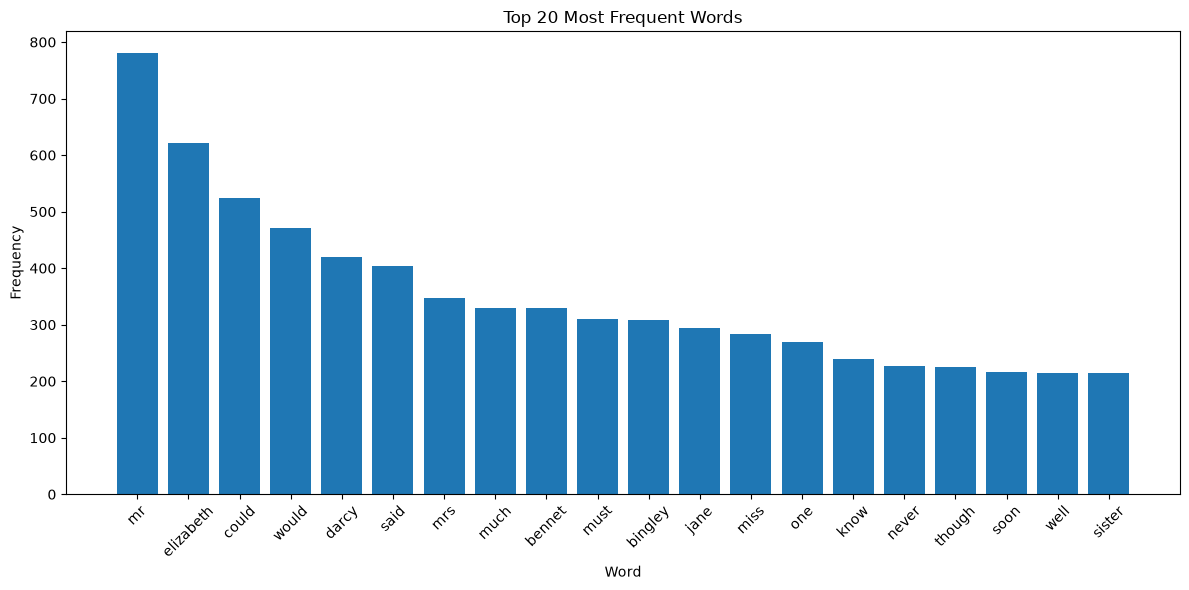

In [151]:
import matplotlib.pyplot as plt

top20 = fdist.most_common(20) #list of tuples

words = [word for word, count in top20] #splits tuples into 2 lists
counts = [count for word, count in top20]

plt.figure(figsize=(12,6)) #canvas size in inches
plt.bar(words, counts) #draws vertical bars for x and y axis

plt.title("Top 20 Most Frequent Words") #text labels for title, x and y
plt.xlabel("Word")
plt.ylabel("Frequency")

plt.xticks(rotation=45) #rotates labels on X-axis by 45 degrees for readability

plt.tight_layout() #automatically adjusts padding around the chart accordingly

plt.savefig("../images/top20_words.png")

plt.show()


#### 2. Top Words Excluding Character Names and Honorifics

To better understand the novel's language, character names and honorifics are excluded before plotting the most frequent remaining words.

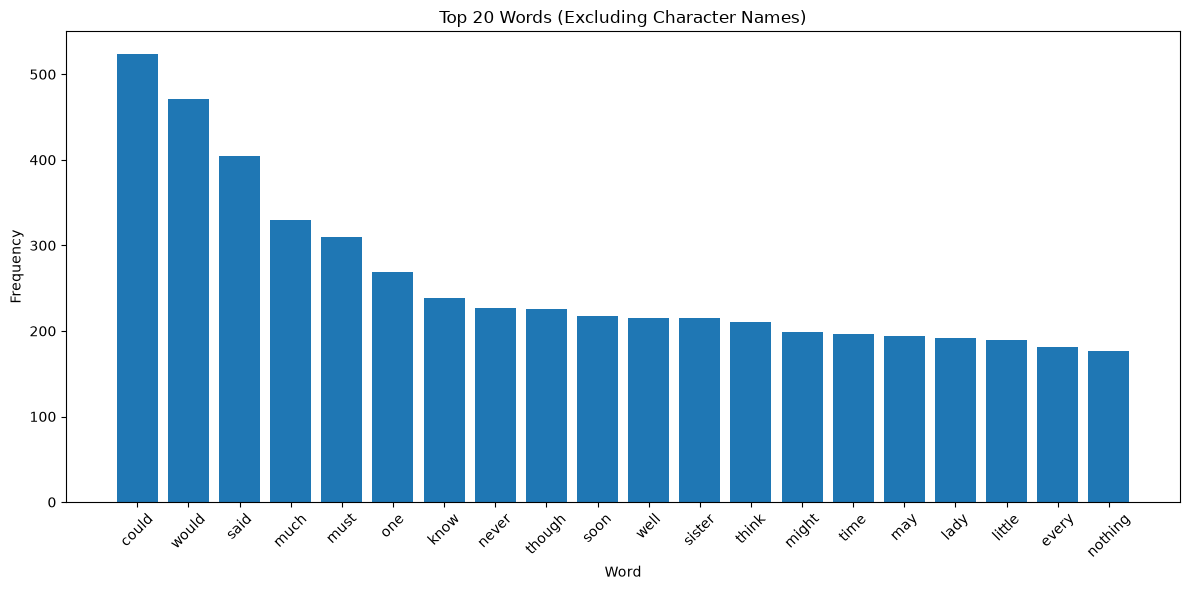

In [152]:
top20 = fdist_no_characters.most_common(20) #list of tuples

words = [word for word, count in top20] #splits tuples into 2 lists
counts = [count for word, count in top20]

plt.figure(figsize=(12,6)) #canvas size in inches
plt.bar(words, counts) #draws vertical bars for x and y axis

plt.title("Top 20 Words (Excluding Character Names)") #text labels for title, x and y
plt.xlabel("Word")
plt.ylabel("Frequency")

plt.xticks(rotation=45) #rotates labels on X-axis by 45 degrees for readability

plt.tight_layout() #automatically adjusts padding around the chart accordingly

plt.savefig("../images/top20_words_no_characters.png")

plt.show()


#### 3. Character Mentions

The following chart compares the frequency of references to the major characters throughout the novel.

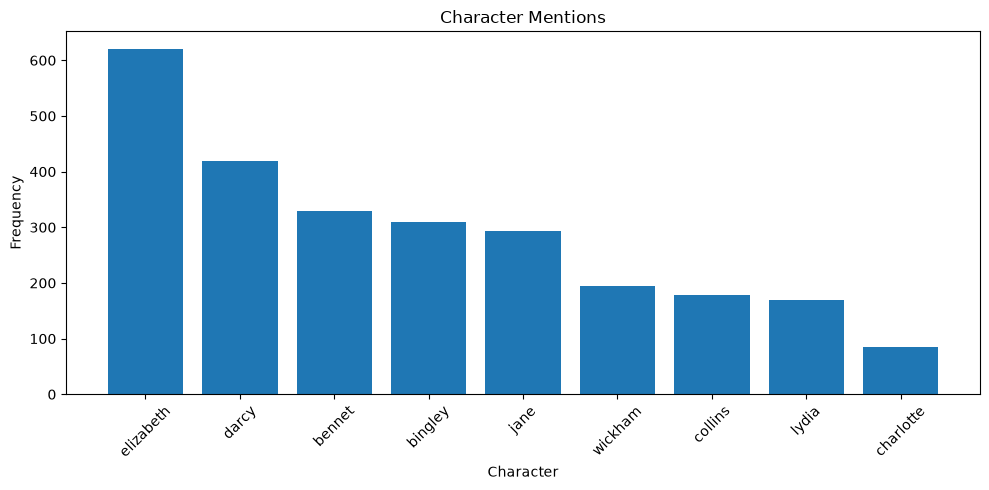

In [153]:
characters = [
    "elizabeth",
    "darcy",
    "bennet",
    "bingley",
    "jane",
    "wickham",
    "collins",
    "lydia",
    "charlotte"
]

mentions = [fdist[word] for word in characters]

plt.figure(figsize=(10,5))
plt.bar(characters, mentions)

plt.title("Character Mentions")
plt.xlabel("Character")
plt.ylabel("Frequency")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig("../images/character_mentions.png")

plt.show()

Elizabeth is mentioned substantially more often than any other major character, reinforcing her role as the primary focus of the narrative.

#### 4. Word Length Distribution

This histogram illustrates the distribution of word lengths used throughout the novel.

It complements the earlier vocabulary statistics by showing how word lengths are distributed rather than only reporting averages.

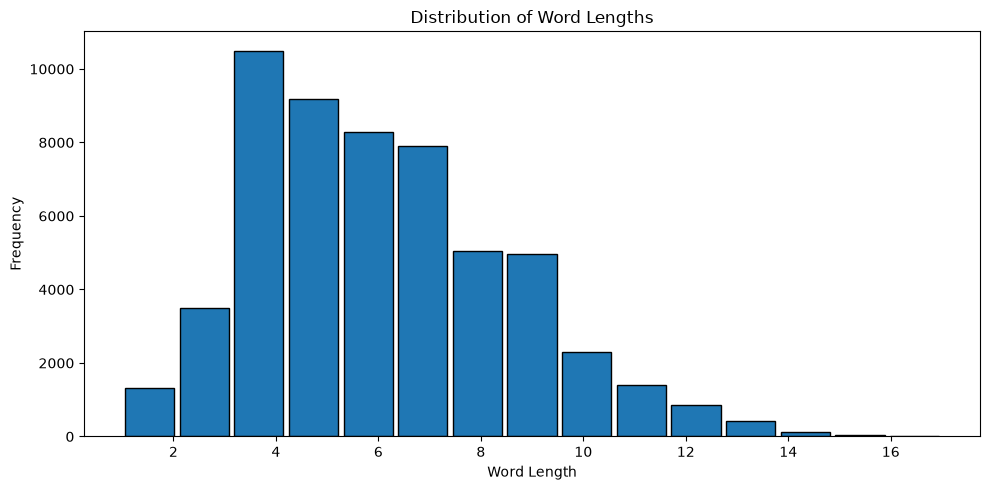

In [154]:
word_lengths = [len(word) for word in tokens_clean]

plt.figure(figsize=(10,5))

plt.hist(word_lengths, bins=15, edgecolor='black', rwidth=0.9) 
#automatically calculates how many times each word length occurs and groups them

plt.title("Distribution of Word Lengths")
plt.xlabel("Word Length")
plt.ylabel("Frequency")

plt.tight_layout()

plt.savefig("../images/word_length_distribution.png")

plt.show()

The histogram shows that most words are relatively short, with the highest concentration between four and seven characters. Longer words occur much less frequently, reflecting their more specialised use in the novel.

## Conclusion

This project demonstrated an end-to-end text analysis workflow using Python.

Starting from the HTML version of *Pride and Prejudice* obtained from Project Gutenberg, the novel was cleaned, preprocessed, and analysed using Natural Language Processing techniques.

Key findings include:

- Elizabeth is the most frequently mentioned character, highlighting her central role in the narrative.
- Dialogue-related words remain prominent after preprocessing, reflecting the conversational nature of the novel.
- Character names and family-related terms occur frequently, suggesting that interpersonal relationships form a major focus of the story.
- The novel exhibits a lexical diversity of approximately **0.122**, indicating a varied vocabulary despite repeated references to key characters.

This project demonstrates practical experience with web scraping, HTML parsing, text preprocessing, exploratory data analysis, and data visualisation using Python.

### Limitations

Several limitations should be noted:

- The analysis is based on a single novel and may not generalise to Jane Austen's complete body of work.
- Word frequency alone cannot fully capture themes or narrative meaning.
- Character names and common dialogue verbs strongly influence frequency-based analyses.
- More advanced NLP techniques could provide deeper insights.

### Future Improvements

Potential extensions to this project include:

- Comparing multiple novels by Jane Austen.
- Analysing character interactions across chapters.
- Performing sentiment analysis on dialogue.
- Building an interactive dashboard using Streamlit.
- Creating word clouds and chapter-level visualisations.